In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from sklearn.datasets import make_moons, make_circles, load_breast_cancer
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    classification_report, confusion_matrix
)
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor': '#0d1929',
    'axes.facecolor':   '#080c14',
    'axes.edgecolor':   '#1a2e4a',
    'axes.labelcolor':  '#8aaccc',
    'text.color':       '#c8d6f0',
    'xtick.color':      '#5a7090',
    'ytick.color':      '#5a7090',
    'grid.color':       '#1a2e4a',
    'grid.alpha':       0.45,
})
print("All imports OK.")

All imports OK.


make_moons   shape: (400, 2) | classes: [200 200]
make_circles shape: (400, 2) | classes: [200 200]


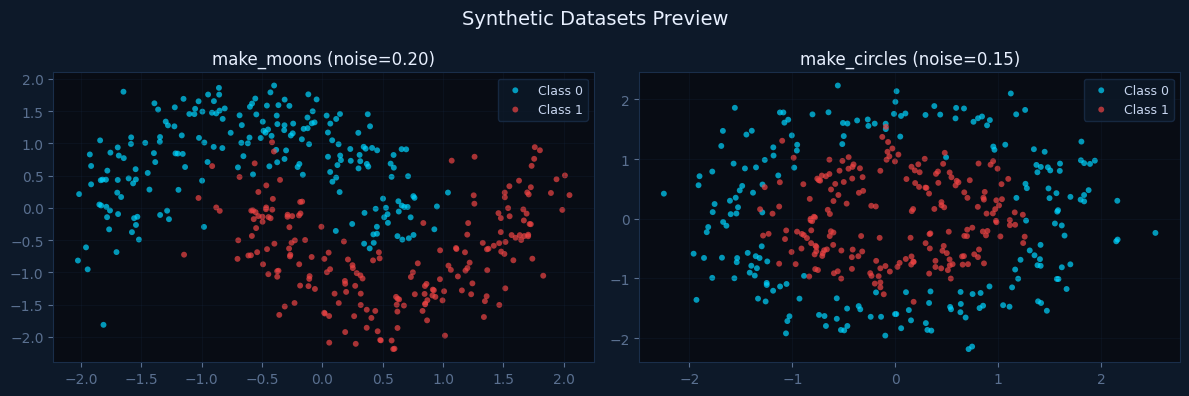

Preview saved.


In [2]:
np.random.seed(42)

X_moons, y_moons = make_moons(n_samples=400, noise=0.20, random_state=42)
X_circles, y_circles = make_circles(n_samples=400, noise=0.15, factor=0.5, random_state=42)

# Scale both
scaler_m = StandardScaler()
scaler_c = StandardScaler()
X_moons_s   = scaler_m.fit_transform(X_moons)
X_circles_s = scaler_c.fit_transform(X_circles)

print("make_moons   shape:", X_moons.shape,   "| classes:", np.bincount(y_moons))
print("make_circles shape:", X_circles.shape, "| classes:", np.bincount(y_circles))

# Quick preview plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, X, y, title in zip(
    axes,
    [X_moons_s, X_circles_s],
    [y_moons, y_circles],
    ['make_moons (noise=0.20)', 'make_circles (noise=0.15)']
):
    ax.scatter(X[y==0,0], X[y==0,1], color='#00d4ff', s=18, alpha=0.7, label='Class 0', edgecolors='none')
    ax.scatter(X[y==1,0], X[y==1,1], color='#ef4444', s=18, alpha=0.7, label='Class 1', edgecolors='none')
    ax.set_title(title, fontsize=12, color='#e8f0ff')
    ax.legend(facecolor='#0d1929', labelcolor='#c8d6f0', edgecolor='#1a2e4a', fontsize=9)
    ax.grid(True, alpha=0.2)
plt.suptitle("Synthetic Datasets Preview", fontsize=14, color='#e8f0ff')
plt.tight_layout()
plt.savefig('datasets_preview.png', dpi=130, bbox_inches='tight', facecolor='#0d1929')
plt.show()
print("Preview saved.")

In [3]:
def plot_decision_boundary(ax, model, X, y, title, resolution=280):
    margin = 0.6
    x1_min, x1_max = X[:,0].min()-margin, X[:,0].max()+margin
    x2_min, x2_max = X[:,1].min()-margin, X[:,1].max()+margin
    xx, yy = np.meshgrid(
        np.linspace(x1_min, x1_max, resolution),
        np.linspace(x2_min, x2_max, resolution)
    )
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

    ax.contourf(xx, yy, Z, alpha=0.22,
                cmap=mcolors.ListedColormap(['#00d4ff', '#ef4444']),
                levels=[-0.5, 0.5, 1.5])
    ax.contour(xx, yy, Z, levels=[0.5],
               colors='white', linewidths=1.2, linestyles='--', alpha=0.7)

    ax.scatter(X[y==0,0], X[y==0,1], color='#00d4ff', s=16, alpha=0.75,
               edgecolors='none', label='Class 0')
    ax.scatter(X[y==1,0], X[y==1,1], color='#ef4444', s=16, alpha=0.75,
               edgecolors='none', label='Class 1')

    # Mark support vectors
    sv = model.support_vectors_
    ax.scatter(sv[:,0], sv[:,1], s=60, facecolors='none',
               edgecolors='white', linewidths=1.0, alpha=0.7, label='Support Vectors')

    acc = accuracy_score(y, model.predict(X))
    ax.set_title(f"{title}\nAcc: {acc:.3f} | SVs: {len(sv)}", fontsize=10, color='#e8f0ff')
    ax.legend(facecolor='#0d1929', labelcolor='#c8d6f0', edgecolor='#1a2e4a', fontsize=7)
    ax.grid(True, alpha=0.15)

print("Decision boundary helper function defined.")

Decision boundary helper function defined.


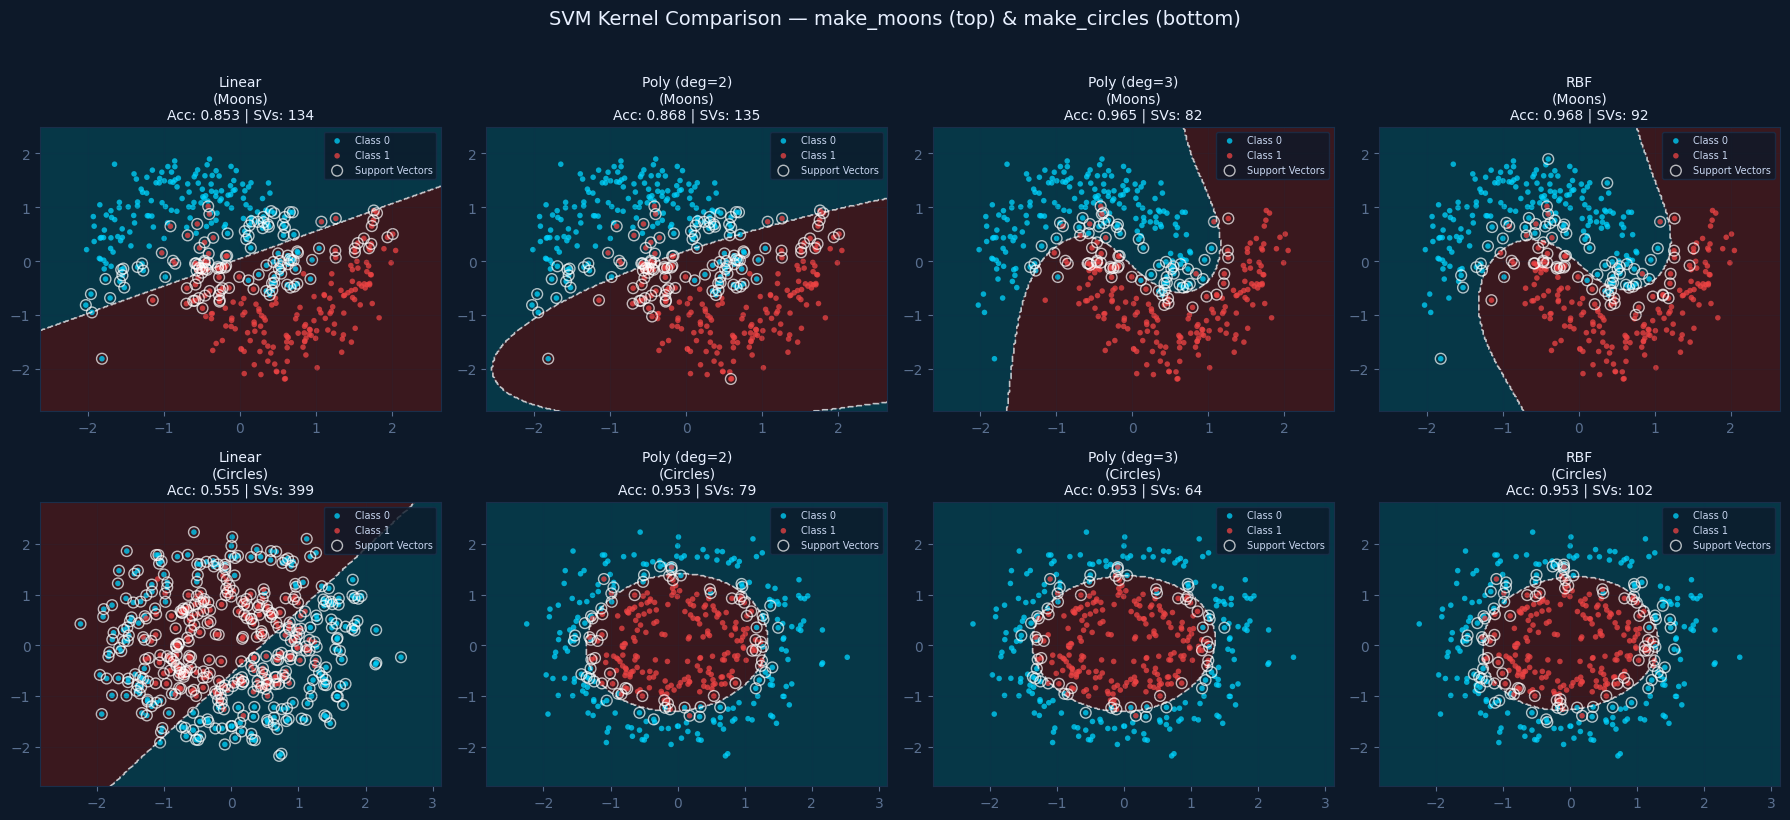

SVM kernel comparison plot saved.


In [4]:
kernels_config = [
    ('Linear',       SVC(kernel='linear', C=1.0, random_state=42)),
    ('Poly (deg=2)', SVC(kernel='poly', degree=2, C=1.0, gamma='scale', coef0=1, random_state=42)),
    ('Poly (deg=3)', SVC(kernel='poly', degree=3, C=1.0, gamma='scale', coef0=1, random_state=42)),
    ('RBF',          SVC(kernel='rbf',  C=1.0, gamma='scale', random_state=42)),
]

fig, axes = plt.subplots(2, 4, figsize=(18, 8))

for col, (name, svm) in enumerate(kernels_config):
    for row, (X, y, ds_name) in enumerate([
        (X_moons_s,   y_moons,   'Moons'),
        (X_circles_s, y_circles, 'Circles')
    ]):
        svm_fit = SVC(**{k:v for k,v in svm.get_params().items()})
        svm_fit.fit(X, y)
        plot_decision_boundary(axes[row, col], svm_fit, X, y,
                               f"{name}\n({ds_name})")

plt.suptitle("SVM Kernel Comparison — make_moons (top) & make_circles (bottom)",
             fontsize=14, color='#e8f0ff', y=1.02)
plt.tight_layout()
plt.savefig('svm_kernels_all.png', dpi=130, bbox_inches='tight', facecolor='#0d1929')
plt.show()
print("SVM kernel comparison plot saved.")

In [5]:
print("=" * 65)
print(f"{'Kernel':<20} {'Moons Acc':>12} {'Moons SVs':>12} {'Circles Acc':>13} {'Circles SVs':>13}")
print("=" * 65)

kernel_results = {}
for name, svm in kernels_config:
    results = {}
    for ds_label, X, y in [('moons', X_moons_s, y_moons), ('circles', X_circles_s, y_circles)]:
        clf = SVC(**{k:v for k,v in svm.get_params().items()})
        clf.fit(X, y)
        results[ds_label] = {'acc': accuracy_score(y, clf.predict(X)), 'svs': len(clf.support_vectors_)}
    kernel_results[name] = results
    print(f"  {name:<18} {results['moons']['acc']:>12.4f} {results['moons']['svs']:>12d} "
          f"{results['circles']['acc']:>13.4f} {results['circles']['svs']:>13d}")
print("=" * 65)

Kernel                  Moons Acc    Moons SVs   Circles Acc   Circles SVs
  Linear                   0.8525          134        0.5550           399
  Poly (deg=2)             0.8675          135        0.9525            79
  Poly (deg=3)             0.9650           82        0.9525            64
  RBF                      0.9675           92        0.9525           102


In [6]:
data = load_breast_cancer()
X_bc, y_bc = data.data, data.target

print("Breast Cancer Dataset")
print("  Shape   :", X_bc.shape)
print("  Classes :", data.target_names)
print("  Counts  :", np.bincount(y_bc))

scaler_bc = StandardScaler()
X_bc_s = scaler_bc.fit_transform(X_bc)

X_bc_train, X_bc_test, y_bc_train, y_bc_test = train_test_split(
    X_bc_s, y_bc, test_size=0.20, random_state=42, stratify=y_bc
)
print(f"  Train   : {X_bc_train.shape[0]} | Test: {X_bc_test.shape[0]}")

Breast Cancer Dataset
  Shape   : (569, 30)
  Classes : ['malignant' 'benign']
  Counts  : [212 357]
  Train   : 455 | Test: 114


In [7]:
param_grid = {
    'C':     [0.01, 0.1, 1, 10, 100],
    'gamma': [0.001, 0.01, 0.1, 1, 10],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
grid_search = GridSearchCV(
    SVC(kernel='rbf', probability=True, random_state=42),
    param_grid,
    cv=cv,
    scoring='accuracy',
    n_jobs=-1,
    verbose=0
)
grid_search.fit(X_bc_train, y_bc_train)

best_params = grid_search.best_params_
best_cv_score = grid_search.best_score_

print("GridSearchCV Complete")
print("=" * 45)
print(f"  Best C     : {best_params['C']}")
print(f"  Best gamma : {best_params['gamma']}")
print(f"  Best CV Acc: {best_cv_score:.4f}")
print("=" * 45)

GridSearchCV Complete
  Best C     : 10
  Best gamma : 0.01
  Best CV Acc: 0.9758


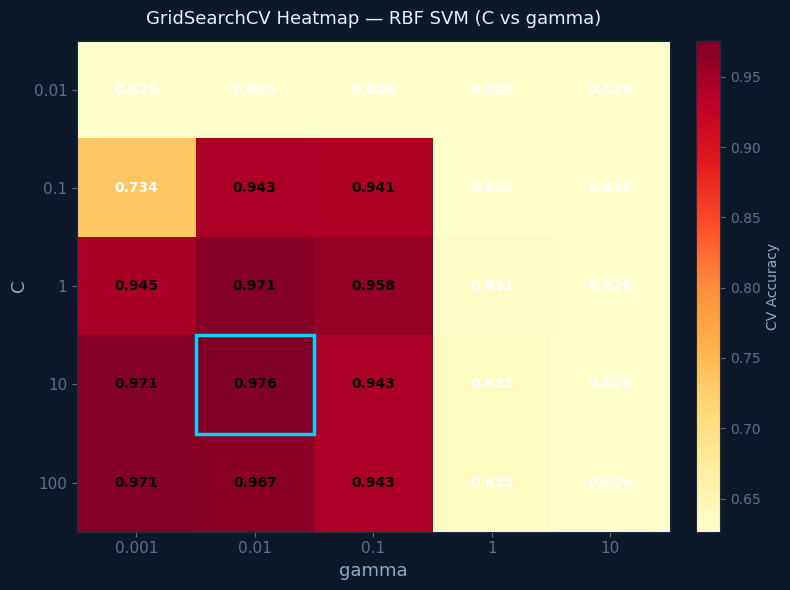

Heatmap saved. Best: C=10, gamma=0.01


In [8]:
C_vals     = param_grid['C']
gamma_vals = param_grid['gamma']

# Reshape CV mean scores into grid
scores_grid = grid_search.cv_results_['mean_test_score'].reshape(len(C_vals), len(gamma_vals))

fig, ax = plt.subplots(figsize=(8, 6))

import matplotlib.colors as mcolors
cmap = plt.cm.get_cmap('YlOrRd')
im = ax.imshow(scores_grid, interpolation='nearest', cmap=cmap, aspect='auto')

ax.set_xticks(range(len(gamma_vals)))
ax.set_yticks(range(len(C_vals)))
ax.set_xticklabels([str(g) for g in gamma_vals], fontsize=11)
ax.set_yticklabels([str(c) for c in C_vals], fontsize=11)
ax.set_xlabel('gamma', fontsize=13)
ax.set_ylabel('C', fontsize=13)
ax.set_title('GridSearchCV Heatmap — RBF SVM (C vs gamma)', fontsize=13, color='#e8f0ff', pad=12)

# Annotate cells
for i in range(len(C_vals)):
    for j in range(len(gamma_vals)):
        val = scores_grid[i, j]
        txt_clr = 'black' if val > scores_grid.max() * 0.85 else 'white'
        ax.text(j, i, f'{val:.3f}', ha='center', va='center',
                fontsize=10, color=txt_clr, fontweight='bold')

# Highlight best cell
best_c_idx = C_vals.index(best_params['C'])
best_g_idx = gamma_vals.index(best_params['gamma'])
rect = plt.Rectangle((best_g_idx-0.5, best_c_idx-0.5), 1, 1,
                      linewidth=2.5, edgecolor='#00d4ff', facecolor='none')
ax.add_patch(rect)

plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label='CV Accuracy')
plt.tight_layout()
plt.savefig('gridsearch_heatmap.png', dpi=130, bbox_inches='tight', facecolor='#0d1929')
plt.show()
print(f"Heatmap saved. Best: C={best_params['C']}, gamma={best_params['gamma']}")

In [9]:
best_svm = SVC(kernel='rbf', C=best_params['C'], gamma=best_params['gamma'],
               probability=True, random_state=42)
best_svm.fit(X_bc_train, y_bc_train)

classifiers = {
    f'SVM RBF (C={best_params["C"]}, γ={best_params["gamma"]})':
        best_svm,
    'Logistic Regression':
        LogisticRegression(max_iter=2000, random_state=42),
    'KNN (K=5)':
        KNeighborsClassifier(n_neighbors=5),
    'Random Forest (100 trees)':
        RandomForestClassifier(n_estimators=100, random_state=42),
    'SVM Linear':
        SVC(kernel='linear', C=1.0, probability=True, random_state=42),
}

results = {}
for name, clf in classifiers.items():
    clf.fit(X_bc_train, y_bc_train)
    y_pred  = clf.predict(X_bc_test)
    y_proba = clf.predict_proba(X_bc_test)[:, 1]
    results[name] = {
        'Accuracy':  accuracy_score(y_bc_test, y_pred),
        'F1 Score':  f1_score(y_bc_test, y_pred, average='weighted'),
        'AUC-ROC':   roc_auc_score(y_bc_test, y_proba),
    }

print("=" * 75)
print(f"{'Model':<40} {'Accuracy':>10} {'F1 Score':>10} {'AUC-ROC':>10}")
print("=" * 75)
for name, metrics in results.items():
    print(f"  {name:<38} {metrics['Accuracy']:>10.4f} {metrics['F1 Score']:>10.4f} {metrics['AUC-ROC']:>10.4f}")
print("=" * 75)

Model                                      Accuracy   F1 Score    AUC-ROC
  SVM RBF (C=10, γ=0.01)                     0.9825     0.9825     0.9980
  Logistic Regression                        0.9825     0.9825     0.9954
  KNN (K=5)                                  0.9649     0.9647     0.9792
  Random Forest (100 trees)                  0.9561     0.9560     0.9937
  SVM Linear                                 0.9737     0.9737     0.9964


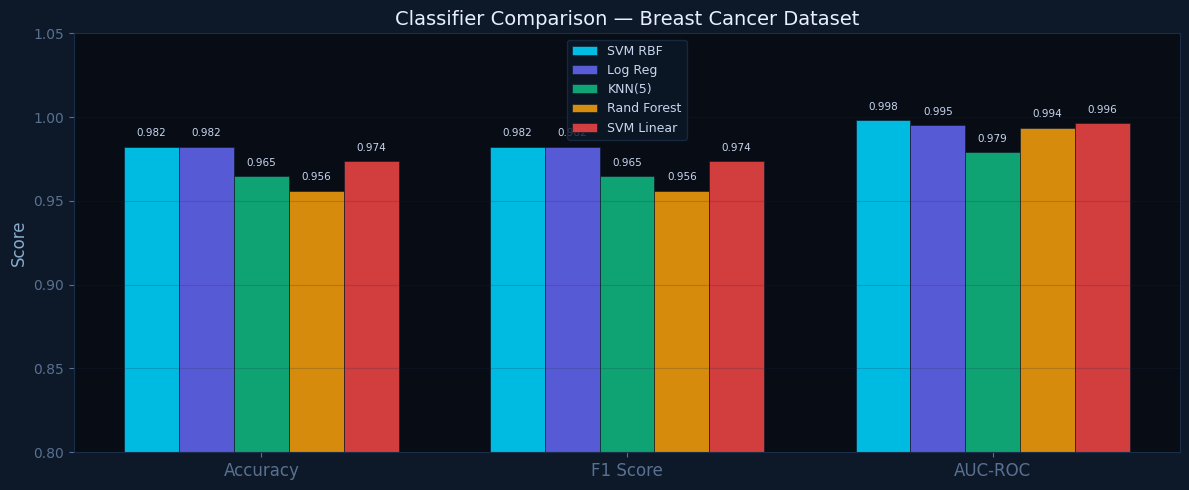

Classifier comparison chart saved.


In [10]:
model_names   = list(results.keys())
short_names   = ['SVM RBF', 'Log Reg', 'KNN(5)', 'Rand Forest', 'SVM Linear']
metrics_list  = ['Accuracy', 'F1 Score', 'AUC-ROC']
colors_models = ['#00d4ff', '#6366f1', '#10b981', '#f59e0b', '#ef4444']

x   = np.arange(len(metrics_list))
w   = 0.15
fig, ax = plt.subplots(figsize=(12, 5))

for i, (name, sname, clr) in enumerate(zip(model_names, short_names, colors_models)):
    vals = [results[name][m] for m in metrics_list]
    bars = ax.bar(x + i*w, vals, w, label=sname, color=clr,
                  alpha=0.88, edgecolor='#0d1929', linewidth=0.5)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.005,
                f'{val:.3f}', ha='center', va='bottom',
                fontsize=7.5, color='#c8d6f0')

ax.set_xticks(x + w*2)
ax.set_xticklabels(metrics_list, fontsize=12)
ax.set_ylim([0.80, 1.05])
ax.set_ylabel("Score", fontsize=12)
ax.set_title("Classifier Comparison — Breast Cancer Dataset", fontsize=14, color='#e8f0ff')
ax.legend(facecolor='#0d1929', edgecolor='#1a2e4a', labelcolor='#c8d6f0', fontsize=9)
ax.grid(True, axis='y', alpha=0.2)
plt.tight_layout()
plt.savefig('classifier_comparison.png', dpi=130, bbox_inches='tight', facecolor='#0d1929')
plt.show()
print("Classifier comparison chart saved.")

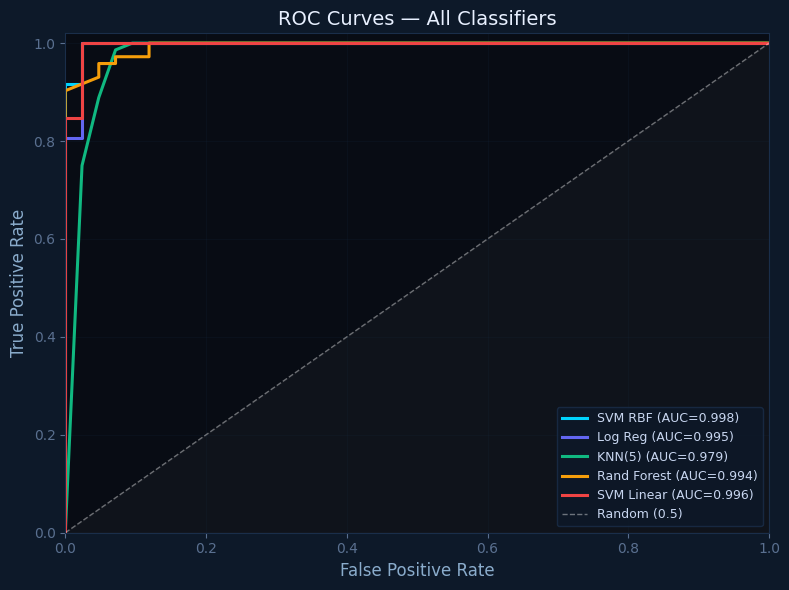

ROC curves saved.


In [11]:
from sklearn.metrics import roc_curve

fig, ax = plt.subplots(figsize=(8, 6))

for (name, clf), sname, clr in zip(classifiers.items(), short_names, colors_models):
    y_proba = clf.predict_proba(X_bc_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_bc_test, y_proba)
    auc_val = roc_auc_score(y_bc_test, y_proba)
    ax.plot(fpr, tpr, color=clr, linewidth=2.2,
            label=f'{sname} (AUC={auc_val:.3f})')

ax.plot([0,1],[0,1],'w--', linewidth=1, alpha=0.4, label='Random (0.5)')
ax.fill_between([0,1],[0,1], alpha=0.03, color='white')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves — All Classifiers', fontsize=14, color='#e8f0ff')
ax.legend(facecolor='#0d1929', edgecolor='#1a2e4a', labelcolor='#c8d6f0', fontsize=9)
ax.grid(True, alpha=0.15)
ax.set_xlim([0,1]); ax.set_ylim([0,1.02])
plt.tight_layout()
plt.savefig('roc_curves_all.png', dpi=130, bbox_inches='tight', facecolor='#0d1929')
plt.show()
print("ROC curves saved.")

In [12]:
df_final = pd.DataFrame([
    {
        'Model': sname,
        'Kernel/Type': (
            f'RBF C={best_params["C"]} γ={best_params["gamma"]}' if i==0
            else 'L2 Reg' if i==1
            else 'Euclidean K=5' if i==2
            else 'Gini 100 trees' if i==3
            else 'Linear C=1.0'
        ),
        'Accuracy':  round(results[name]['Accuracy'],  4),
        'F1 Score':  round(results[name]['F1 Score'],  4),
        'AUC-ROC':   round(results[name]['AUC-ROC'],   4),
        'Dataset':   'Breast Cancer',
    }
    for i, (name, sname) in enumerate(zip(model_names, short_names))
])

print("=" * 82)
print("                FINAL MODEL COMPARISON TABLE")
print("=" * 82)
print(df_final.to_string(index=False))
print("=" * 82)
winner = df_final.loc[df_final['AUC-ROC'].idxmax(), 'Model']
print(f"\nBest AUC-ROC: {winner}")
print(f"Best Accuracy: {df_final.loc[df_final['Accuracy'].idxmax(), 'Model']}")
print(f"Best F1 Score: {df_final.loc[df_final['F1 Score'].idxmax(), 'Model']}")

                FINAL MODEL COMPARISON TABLE
      Model     Kernel/Type  Accuracy  F1 Score  AUC-ROC       Dataset
    SVM RBF RBF C=10 γ=0.01    0.9825    0.9825   0.9980 Breast Cancer
    Log Reg          L2 Reg    0.9825    0.9825   0.9954 Breast Cancer
     KNN(5)   Euclidean K=5    0.9649    0.9647   0.9792 Breast Cancer
Rand Forest  Gini 100 trees    0.9561    0.9560   0.9937 Breast Cancer
 SVM Linear    Linear C=1.0    0.9737    0.9737   0.9964 Breast Cancer

Best AUC-ROC: SVM RBF
Best Accuracy: SVM RBF
Best F1 Score: SVM RBF
